### Business Problem and Objective:
Business wants to know:
> What type of content (movies vs. TV shows, genres, durations, ratings, etc.) is working best across countries.
> How they can grow in different regions by producing the right type of shows/movies.

Goal: Provide data-driven recommendations for future productions & growth strategy.


### Colab Notebook Link:

**https://colab.research.google.com/drive/1hmofBeYh228giPF1y7IcDfI4Sgo8volI?usp=sharing**

### 1. Import required Libraies

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 2. Load the data

In [ ]:
df = pd.read_csv("netflix.csv")

### 3. Basic Data Analyis

In [ ]:
# Shape of data
print("Shape of dataset:", df.shape)


Shape of dataset: (8807, 12)


In [ ]:
# Top 5 records of the dataframe

df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# Unique Values per column

unique_counts = df.nunique().to_frame("Unique_Values").sort_values(by="Unique_Values", ascending=False)
print("\n--- Unique Values per Column ---")
print(unique_counts)


--- Unique Values per Column ---
              Unique_Values
show_id                8807
title                  8807
description            8775
cast                   7692
director               4528
date_added             1767
country                 748
listed_in               514
duration                220
release_year             74
rating                   17
type                      2


### Exploratory Data Analysis

### Content Type

In [ ]:
# Check unique types in the dataset

print("Unique values in 'type' column:", df['type'].unique())
print("\nCount of each type:")
print(df['type'].value_counts())


Unique values in 'type' column: ['Movie' 'TV Show']

Count of each type:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


/tmp/ipython-input-88302024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=type_counts.index, y=type_counts.values, palette="Reds")


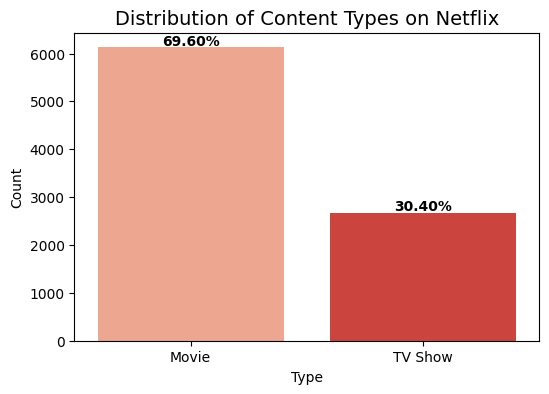

In [ ]:
# Content Type Distribution in the streaming collection

# Get value counts
type_counts = df['type'].value_counts()
total = type_counts.sum()

# Plot
plt.figure(figsize=(6,4))
ax = sns.barplot(x=type_counts.index, y=type_counts.values, palette="Reds")

# Add percentage labels above bars
for i, val in enumerate(type_counts.values):
    percent = (val / total) * 100
    plt.text(i, val + 50, f"{percent:.2f}%", ha='center', fontsize=10, fontweight='bold')

plt.title("Distribution of Content Types on Netflix", fontsize=14)
plt.ylabel("Count")
plt.xlabel("Type")
plt.show()



Quick Insights – Content Type Distribution on Netflix


*   Netflix’s offerings are broadly divided into two formats: Movie and TV Show.
*   Movies make up the majority of the catalog with ~69% of the total content.
*   TV Shows form a smaller share in comparison with ~31% of the total content.

Recommendations:


*  Maintain movies as the backbone to attract casual and global audiences.
*  Expand TV shows strategically to strengthen engagement and retention.







### Release Year

In [ ]:
print("\nCount of releases in each year:")
print(df['release_year'].value_counts())


Count of releases in each year:
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
        ... 
1961       1
1925       1
1959       1
1966       1
1947       1
Name: count, Length: 74, dtype: int64


/tmp/ipython-input-550100973.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=recent_release_counts.index, y=recent_release_counts.values, palette = "Reds")


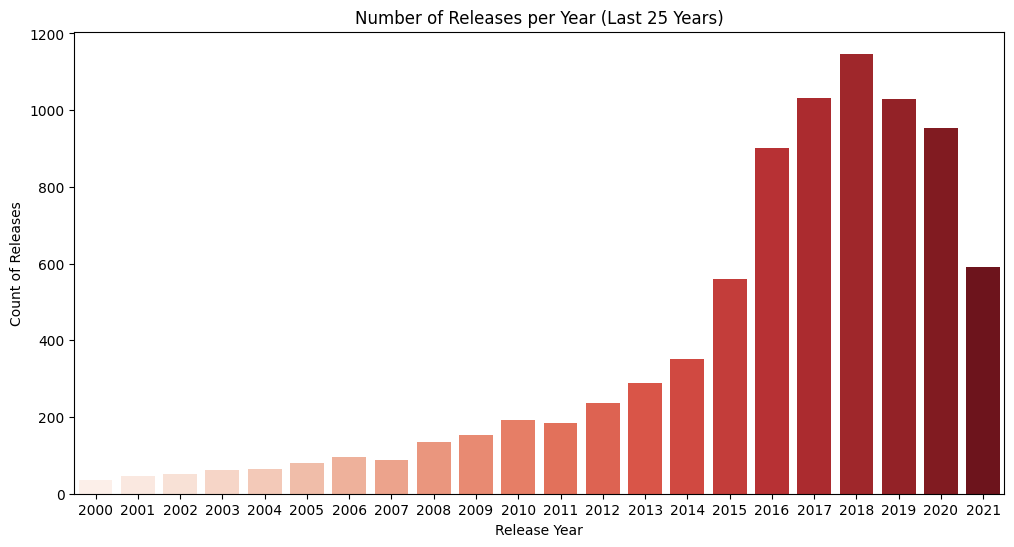

In [ ]:
# Visualize releases for last 25 years, since the release count is huge in recent years.
# Get the current year
current_year = pd.Timestamp.now().year

# Filter for last 25 years
recent_years_df = df[df['release_year'] >= current_year - 25]

# Count of releases per year
recent_release_counts = recent_years_df['release_year'].value_counts().sort_index()

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(x=recent_release_counts.index, y=recent_release_counts.values, palette = "Reds")
plt.title("Number of Releases per Year (Last 25 Years)")
plt.xlabel("Release Year")
plt.ylabel("Count of Releases")
plt.show()

Quick Insights – Release Date Distribution on Netflix


*  The highest release counts are in 2018 (1147), 2017 (1032), 2019 (1030), and 2020 (953).
*   This indicates a significant surge in content production in the last 5–6 years, likely due to platform growth and increased user demand.
*   Years before 1995 (and even many between 1995–2015) show very low counts, often single digits, reflecting either limited platform acquisitions or historical scarcity of digital content.


Recommendations:


*   Allocate more production resources in line with the surge seen in 2017–2019, as this appears to align with user demand growth.
*   Use this release pattern to forecast next year’s content needs, balancing quality and quantity to maintain user engagement.



### Rating

In [ ]:
# Count of each rating
rating_counts = df['rating'].value_counts()

# Print counts
print("\nCount of content by rating:")
print(rating_counts)


Count of content by rating:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [ ]:
# Remove rows where 'rating' contains invalid data like runtime
df = df[~df['rating'].str.contains('min', case=False, na=False)]

# Check remaining ratings
print(df['rating'].unique())

['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' 'NR' nan 'TV-Y7-FV' 'UR']


/tmp/ipython-input-3473765136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.values, y=rating_counts.index, palette="flare")


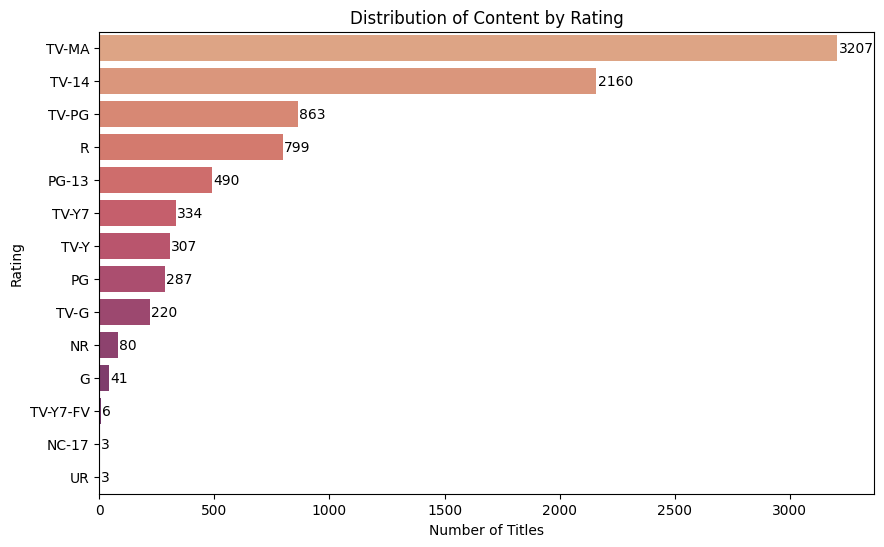

In [ ]:
# Visualization
plt.figure(figsize=(10,6))
sns.barplot(x=rating_counts.values, y=rating_counts.index, palette="flare")
plt.title("Distribution of Content by Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
for i, v in enumerate(rating_counts.values):
    plt.text(v + 5, i, str(v), color='black', va='center')

plt.show()

### Listed_In : Separate Genre

In [ ]:
df["listed_in"]

,listed_in
0,Documentaries
1,"International TV Shows, TV Dramas, TV Mysteries"
2,"Crime TV Shows, International TV Shows, TV Act..."
3,"Docuseries, Reality TV"
4,"International TV Shows, Romantic TV Shows, TV ..."
...,...
8802,"Cult Movies, Dramas, Thrillers"
8803,"Kids' TV, Korean TV Shows, TV Comedies"
8804,"Comedies, Horror Movies"
8805,"Children & Family Movies, Comedies"


In [ ]:
df.rename(columns={"listed_in": "genre"}, inplace=True)

In [ ]:
df["genre"]

,genre
0,Documentaries
1,"International TV Shows, TV Dramas, TV Mysteries"
2,"Crime TV Shows, International TV Shows, TV Act..."
3,"Docuseries, Reality TV"
4,"International TV Shows, Romantic TV Shows, TV ..."
...,...
8802,"Cult Movies, Dramas, Thrillers"
8803,"Kids' TV, Korean TV Shows, TV Comedies"
8804,"Comedies, Horror Movies"
8805,"Children & Family Movies, Comedies"


In [ ]:
all_genre = []

for items in df["genre"].str.split(","):
  all_genre.extend(items)


genre_counts = pd.Series(all_genre).value_counts()
print(genre_counts)

 International Movies        2624
Dramas                       1600
Comedies                     1210
Action & Adventure            859
Documentaries                 829
                             ... 
Romantic Movies                 3
Spanish-Language TV Shows       2
LGBTQ Movies                    1
TV Sci-Fi & Fantasy             1
Sports Movies                   1
Name: count, Length: 73, dtype: int64


/tmp/ipython-input-4104641919.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_genres.index, y=top5_genres.values, palette="Reds")


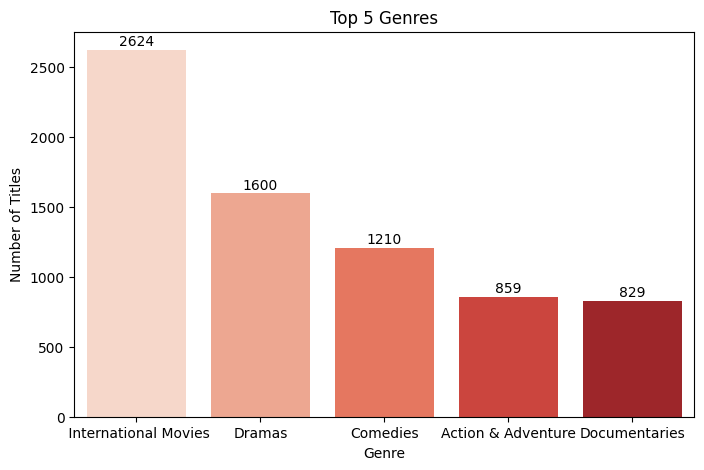

In [ ]:
# Top 5 genres
top5_genres = genre_counts.head(5)

# Visualization: Horizontal Bar Chart
plt.figure(figsize=(8,5))
sns.barplot(x=top5_genres.index, y=top5_genres.values, palette="Reds")
plt.title("Top 5 Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
for i, v in enumerate(top5_genres.values):
    plt.text(i, v+30, str(v), color='black', ha='center')

plt.show()

Quick Insights - Genre:


*   International Movies (2624 titles), Dramas (1600), and Comedies (1210) dominate the dataset, showing a strong focus on broad appeal and story-driven content.
*   Action & Adventure (859) and Documentaries (829) also have substantial representation, indicating diverse content types.
*   Some genres like Romantic Movies (3), Spanish-Language TV Shows (2), LGBTQ Movies (1), and Sports Movies (1) are extremely underrepresented.
*   This indicates that while the platform has mass-appeal content, niche audiences have limited options.

Recommendations:


*   Focus marketing and recommendation algorithms on International Movies, Dramas, Comedies, and Action & Adventure, which attract the largest audiences
*   Since International Movies dominate, explore regional content strategies to further engage viewers.








### Top 20 Countries with most streamed content

In [ ]:
# Top 20 countries
top_countries = df['country'].dropna().value_counts().head(20)
print("Top 20 Countries:\n", top_countries)



Top 20 Countries:
 country
United States                    2815
India                             972
United Kingdom                    419
Japan                             245
South Korea                       199
Canada                            181
Spain                             145
France                            124
Mexico                            110
Egypt                             106
Turkey                            105
Nigeria                            95
Australia                          87
Taiwan                             81
Indonesia                          79
Brazil                             77
Philippines                        75
United Kingdom, United States      75
United States, Canada              73
Germany                            67
Name: count, dtype: int64


### Top 20 directors

In [ ]:
top_directors = df['director'].dropna().value_counts().head(20)
print("\nTop 20 Directors:\n", top_directors)



Top 20 Directors:
 director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Jay Chapman               12
Martin Scorsese           12
Youssef Chahine           12
Steven Spielberg          11
Don Michael Paul          10
David Dhawan               9
Lance Bangs                8
Robert Rodriguez           8
Yılmaz Erdoğan             8
Kunle Afolayan             8
Fernando Ayllón            8
Troy Miller                8
Hakan Algül                8
Quentin Tarantino          8
Name: count, dtype: int64


### Top 20 Actors

In [ ]:
all_actors = []
for cast_list in df['cast'].dropna().str.split(","):
    all_actors.extend([actor.strip() for actor in cast_list])

top_actors = pd.Series(all_actors).value_counts().head(20)
print("\nTop 20 Actors:\n", top_actors)


Top 20 Actors:
 Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Takahiro Sakurai     32
Naseeruddin Shah     32
Rupa Bhimani         31
Om Puri              30
Akshay Kumar         30
Yuki Kaji            29
Amitabh Bachchan     28
Paresh Rawal         28
Boman Irani          27
Rajesh Kava          26
Vincent Tong         26
Andrea Libman        25
Kareena Kapoor       25
John Cleese          24
Samuel L. Jackson    24
Tara Strong          23
Jigna Bhardwaj       23
Name: count, dtype: int64


Quick Insights - Top Performers:


*   United States (2815 titles) and India (972 titles) dominate content production, reflecting strong platform sourcing and high production volumes.
*   Other notable contributors include the United Kingdom, Japan, South Korea and Canada, showing some geographic diversity.
*   Directors like Rajiv Chilaka (19 titles), Raúl Campos & Jan Suter (18), and Suhas Kadav (16) are highly prolific, suggesting consistent partnerships or popular franchises.
*   Renowned global directors like Martin Scorsese (12) and Steven Spielberg (11) also appear, showing platform alignment with high-profile filmmakers.
*   Actors such as Anupam Kher (43), Shah Rukh Khan (35), and Julie Tejwani (33) dominate appearances, highlighting star-driven content.
*   Prominent global actors like Samuel L. Jackson (24) and John Cleese (24) indicate diverse casting across international titles.
*   The long tail of actors shows that while a few actors dominate, there is significant diversity in the cast pool.


Recommendations:


*   Expand acquisitions from underrepresented countries (Nigeria, Egypt, Turkey, Philippines, Indonesia) to enhance global diversity.
*   Strengthen collaboration with high-performing directors to secure popular or exclusive content.
*   Promote content featuring top actors for marketing campaigns to attract fan followings.

















### Best Day of the Week to Release the Movies/TV Shows

/tmp/ipython-input-1609282481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["day_of_the_week"], order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"], palette="Reds")


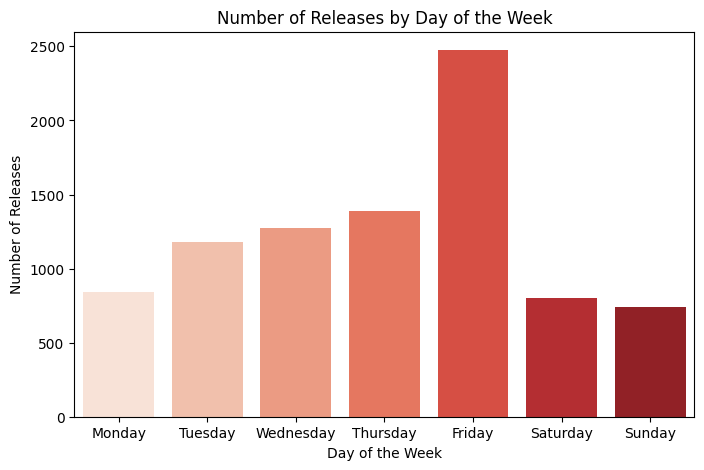

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['day_of_the_week'] = df['date_added'].dt.day_name()

plt.figure(figsize=(8,5))
sns.countplot(x=df["day_of_the_week"], order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"], palette="Reds")
plt.title("Number of Releases by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Releases")
plt.show()

### TV Show Releases

/tmp/ipython-input-3683950579.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tv_day_counts.values,y=tv_day_counts.index, palette="flare")


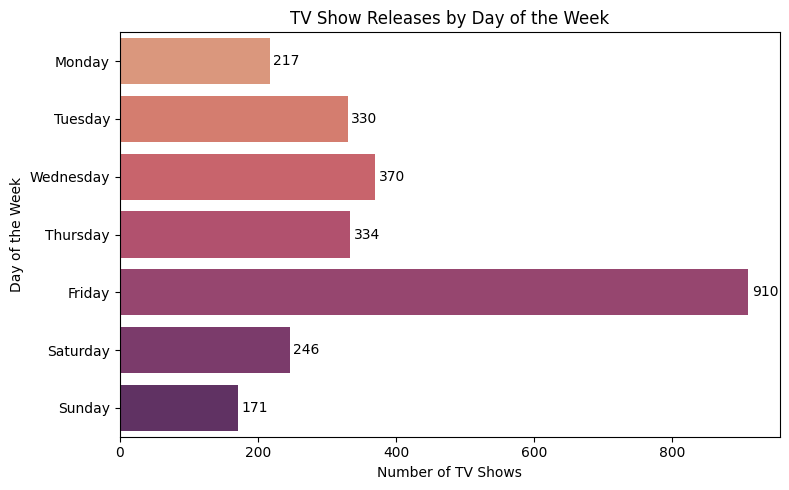

In [ ]:
# Filter only TV Shows
tv_df = df[df['type'] == "TV Show"].copy()

# Count of TV show releases per day
tv_day_counts = tv_df['day_of_the_week'].value_counts().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)


# Convert 'date_added' to datetime if not already done
tv_df['date_added'] = pd.to_datetime(tv_df['date_added'], errors='coerce')

# Derive day of the week
tv_df['day_of_the_week'] = tv_df['date_added'].dt.day_name()

plt.figure(figsize=(8,5))
ax = sns.barplot(x=tv_day_counts.values,y=tv_day_counts.index, palette="flare")
plt.title("TV Show Releases by Day of the Week")
plt.xlabel("Number of TV Shows")
plt.ylabel("Day of the Week")

# Add data labels
for i, v in enumerate(tv_day_counts.values):
    ax.text(v + 5, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()



Quick Insights - Releases on a day of the Week



*   Friday has the highest number of releases (2475), almost double that of Thursday, indicating that platforms prefer launching new content at the end of the workweek.
*   This aligns with typical user behavior, as weekend viewership increases, giving content maximum exposure.
*   Tuesday, Wednesday, and Thursday also have significant releases, showing that platforms distribute content through the week, possibly to maintain daily engagement.



Recommendations:
*   Continue prioritizing Friday releases for high-profile titles to maximize weekend viewership and social media buzz.
*   Consider Thursday or Wednesday releases for mid-tier or niche content to maintain consistent engagement throughout the week.





# Summary - Recommendations and Insights

# Content Type Distribution

**Insights:**

* Movies constitute ~69% of Netflix’s catalog; TV Shows make up ~31%.
* Movies dominate, appealing to casual and global audiences.

**Recommendations:**

* Maintain movies as the backbone to attract broad audiences.
* Strategically expand TV Shows to strengthen engagement and retention.

# Release Date Distribution

**Insights:**

* Highest release counts occurred in 2017–2020, indicating a surge in content production.
* Years before 1995 and many between 1995–2015 show very low counts, reflecting historical scarcity or limited acquisitions.

**Recommendations:**

* Allocate production resources in line with recent surges to match user demand.
* Use historical release patterns to forecast content needs, balancing quality and quantity.

# Top Performers (Countries, Directors, Actors)

**Insights:**

* United States (2815 titles) and India (972 titles) dominate; UK, Japan, South Korea, and Canada contribute significantly.
* Directors like Rajiv Chilaka, Raúl Campos & Jan Suter are highly prolific; renowned directors (e.g., Scorsese, Spielberg) are present.
* Actors such as Anupam Kher, Shah Rukh Khan, and Julie Tejwani dominate appearances; global actors like Samuel L. Jackson add diversity.

**Recommendations:**

* Expand acquisitions from underrepresented countries (Nigeria, Egypt, Turkey, Philippines, Indonesia).
* Strengthen collaborations with high-performing directors for exclusive or popular content.
* Promote content featuring top actors to leverage star power for marketing.

# Releases by Day of the Week

**Insights:**

* Friday has the highest number of releases (2475), nearly double Thursday, aligning with increased weekend viewership.
* Tuesday, Wednesday, and Thursday also have substantial releases, indicating a distributed release strategy.

**Recommendations:**

* Prioritize Friday releases for high-profile titles to maximize weekend engagement and social media buzz.
* Use Thursday or Wednesday for mid-tier or niche content to maintain consistent engagement during the week.